In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive

In [2]:
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
health_spending_data = pd.read_csv("/content/drive/MyDrive/Refocus/Data Analytics/Final Project/Final Project - Lagmay/state_ave_health_spending_pop.csv")
health_spending_data

,state_usa,avg_health_spending,min_health_spending,max_health_spending,population_estimate
0,Alabama,200.50,50.0,500.0,4903185
1,Alaska,300.25,100.0,750.0,731545
2,Arizona,150.00,25.0,300.0,7278717
3,Arkansas,175.00,75.0,400.0,3017804
4,California,250.75,50.0,600.0,39512223
5,Colorado,225.50,100.0,500.0,5758736
6,Connecticut,300.00,150.0,700.0,3565287
7,Delaware,175.50,75.0,350.0,973764
8,Florida,175.25,50.0,400.0,21477737
9,Georgia,200.00,75.0,450.0,10617423


In [4]:
health_spending_data = health_spending_data.drop_duplicates(subset="state_usa").drop("population_estimate", axis=1)
health_spending_data

,state_usa,avg_health_spending,min_health_spending,max_health_spending
0,Alabama,200.50,50.0,500.0
1,Alaska,300.25,100.0,750.0
2,Arizona,150.00,25.0,300.0
3,Arkansas,175.00,75.0,400.0
4,California,250.75,50.0,600.0
5,Colorado,225.50,100.0,500.0
6,Connecticut,300.00,150.0,700.0
7,Delaware,175.50,75.0,350.0
8,Florida,175.25,50.0,400.0
9,Georgia,200.00,75.0,450.0


In [5]:
min_health_spending_top_5 = health_spending_data[["state_usa", "min_health_spending"]]
min_health_spending_top_5['rank'] = min_health_spending_top_5['min_health_spending'].rank(ascending=False, method="min")
min_health_spending_top_5.loc[min_health_spending_top_5['rank'] <= 5].sort_values(by="min_health_spending", ascending=False)

<ipython-input-5-05d4e3dc0f64>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  min_health_spending_top_5['rank'] = min_health_spending_top_5['min_health_spending'].rank(ascending=False, method="min")


,state_usa,min_health_spending,rank
10,Hawaii,200.0,1.0
20,Massachusetts,200.0,1.0
29,New Jersey,200.0,1.0
38,Rhode Island,200.0,1.0
6,Connecticut,150.0,5.0
19,Maryland,150.0,5.0
28,New Hampshire,150.0,5.0
37,Pennsylvania,150.0,5.0
45,Virginia,150.0,5.0


In [6]:
avg_health_spending_top_5 = health_spending_data[["state_usa", "avg_health_spending"]]
avg_health_spending_top_5['rank'] = avg_health_spending_top_5['avg_health_spending'].rank(ascending=False, method="min")
avg_health_spending_top_5.loc[avg_health_spending_top_5['rank'] <= 5].sort_values(by="avg_health_spending", ascending=False)

<ipython-input-6-2501812f0103>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  avg_health_spending_top_5['rank'] = avg_health_spending_top_5['avg_health_spending'].rank(ascending=False, method="min")


,state_usa,avg_health_spending,rank
10,Hawaii,350.00,1.0
20,Massachusetts,350.00,1.0
29,New Jersey,350.00,1.0
38,Rhode Island,350.00,1.0
1,Alaska,300.25,5.0


In [7]:
max_health_spending_top_5 = health_spending_data[["state_usa", "max_health_spending"]]
max_health_spending_top_5['rank'] = max_health_spending_top_5['max_health_spending'].rank(ascending=False, method="min")
max_health_spending_top_5.loc[max_health_spending_top_5['rank'] <= 5].sort_values(by="max_health_spending", ascending=False)

<ipython-input-7-8ec008902931>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  max_health_spending_top_5['rank'] = max_health_spending_top_5['max_health_spending'].rank(ascending=False, method="min")


,state_usa,max_health_spending,rank
10,Hawaii,800.0,1.0
20,Massachusetts,800.0,1.0
29,New Jersey,800.0,1.0
38,Rhode Island,800.0,1.0
1,Alaska,750.0,5.0


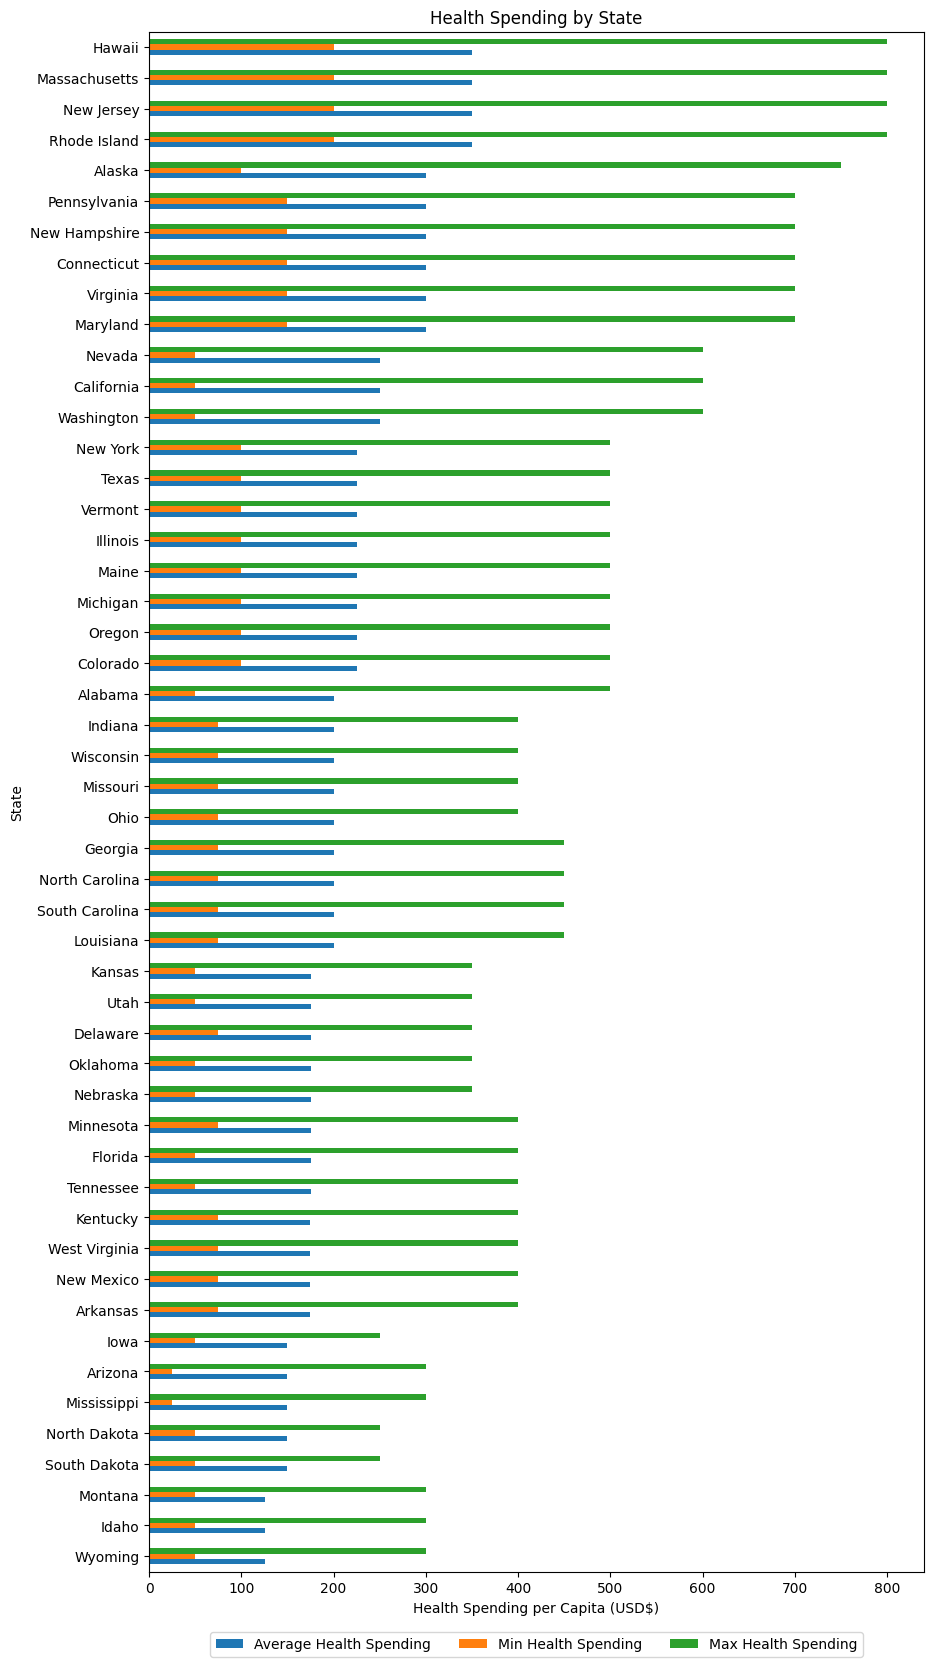

In [37]:
# Sources:
# https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.legend.html

fig, ax = plt.subplots(figsize=(10,20))
health_spending_data.rename(columns={"avg_health_spending": "Average Health Spending", "min_health_spending": "Min Health Spending", "max_health_spending": "Max Health Spending"}).sort_values(by="Average Health Spending").set_index("state_usa").plot(kind="barh", ax=ax)
ax.set_title("Health Spending by State")
ax.set_ylabel("State")
ax.set_xlabel("Health Spending per Capita (USD$)")
ax.legend(loc="lower center", ncols=3, bbox_to_anchor=(0.5, -0.06))

In [9]:
property_profit_data = pd.read_csv("/content/drive/MyDrive/Refocus/Data Analytics/Final Project/Final Project - Lagmay/state_property_profit.csv")
property_profit_data

,state_usa,avg_property_price,min_property_price,max_property_price,avg_comp_profit
0,Alabama,1797.50,1200.0,2500.0,1138459.39
1,Alaska,2684.00,2000.0,3500.0,1969126.59
2,Arizona,2356.75,1500.0,4000.0,2942282.99
3,Arkansas,1499.25,1000.0,2500.0,743958.99
4,California,5832.50,3500.0,9000.0,398315.70
5,Colorado,2987.25,2000.0,4500.0,1225371.32
6,Connecticut,3837.00,3000.0,5500.0,1934226.24
7,Delaware,2289.75,1500.0,3500.0,2265218.99
8,Florida,2763.50,1500.0,5000.0,398984.51
9,Georgia,2065.00,1200.0,3500.0,1193045.59


In [10]:
property_profit_data = property_profit_data.drop_duplicates(subset="state_usa")
property_profit_data

,state_usa,avg_property_price,min_property_price,max_property_price,avg_comp_profit
0,Alabama,1797.50,1200.0,2500.0,1138459.39
1,Alaska,2684.00,2000.0,3500.0,1969126.59
2,Arizona,2356.75,1500.0,4000.0,2942282.99
3,Arkansas,1499.25,1000.0,2500.0,743958.99
4,California,5832.50,3500.0,9000.0,398315.70
5,Colorado,2987.25,2000.0,4500.0,1225371.32
6,Connecticut,3837.00,3000.0,5500.0,1934226.24
7,Delaware,2289.75,1500.0,3500.0,2265218.99
8,Florida,2763.50,1500.0,5000.0,398984.51
9,Georgia,2065.00,1200.0,3500.0,1193045.59


Text(0.5, 0.98, 'Competitors Profit vs. Property Price')

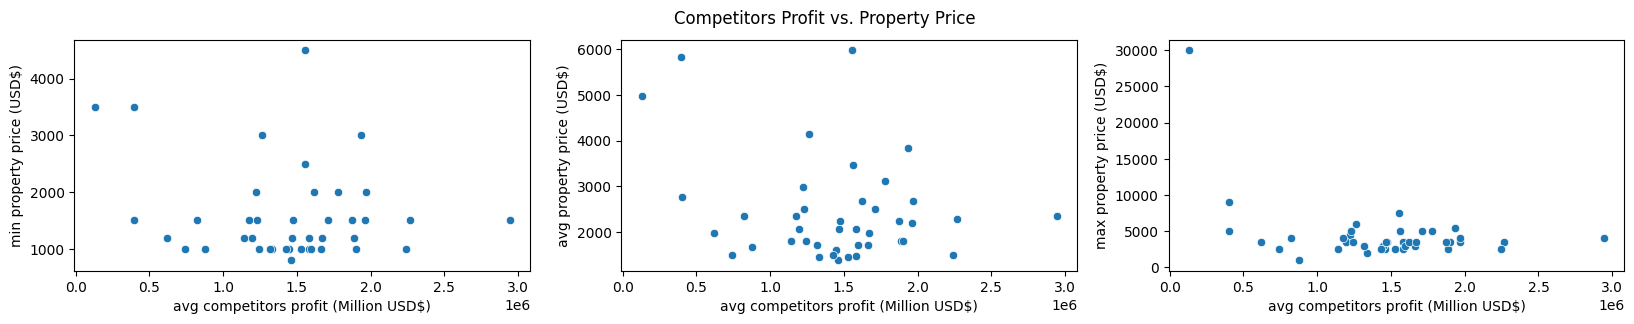

In [11]:
prefixes = ("min", "avg", "max")
fig, ax = plt.subplots(nrows = 1, ncols = len(prefixes), figsize=(20, 3))
for i in range(len(prefixes)):
  sns.scatterplot(data=property_profit_data, x='avg_comp_profit', y=prefixes[i] + '_property_price', ax=ax[i])
  ax[i].set_xlabel("avg competitors profit (Million USD$)")
  ax[i].set_ylabel(prefixes[i] + " property price (USD$)")

plt.suptitle("Competitors Profit vs. Property Price")

In [12]:
property_profit_data.drop(['state_usa'], axis=1).fillna(0).corr()

,avg_property_price,min_property_price,max_property_price,avg_comp_profit
avg_property_price,1.000000,0.981374,0.643342,-0.135229
min_property_price,0.981374,1.000000,0.621754,-0.112661
max_property_price,0.643342,0.621754,1.000000,-0.218236
avg_comp_profit,-0.135229,-0.112661,-0.218236,1.000000


In [13]:
property_price_data = property_profit_data.drop(["avg_comp_profit"], axis = 1).rename(columns={"avg_property_price": "average_property_price", "min_property_price": "minimum_property_price", "max_property_price": "maximum_property_price"})
property_price_data

,state_usa,average_property_price,minimum_property_price,maximum_property_price
0,Alabama,1797.50,1200.0,2500.0
1,Alaska,2684.00,2000.0,3500.0
2,Arizona,2356.75,1500.0,4000.0
3,Arkansas,1499.25,1000.0,2500.0
4,California,5832.50,3500.0,9000.0
5,Colorado,2987.25,2000.0,4500.0
6,Connecticut,3837.00,3000.0,5500.0
7,Delaware,2289.75,1500.0,3500.0
8,Florida,2763.50,1500.0,5000.0
9,Georgia,2065.00,1200.0,3500.0


In [14]:
state_income_data = pd.read_csv('/content/drive/MyDrive/Refocus/Data Analytics/Final Project/Final Project - Lagmay/state_income.csv')
state_income_data = state_income_data.drop_duplicates(subset="state_usa")
state_income_data

,state_usa,average_income,minimum_income,maximum_income
0,Alabama,51113,23999,96993
1,Alaska,76440,35219,134318
2,Arizona,62283,29466,113589
3,Arkansas,48829,23028,90052
4,California,80440,37698,149265
5,Colorado,76240,35636,130714
6,Connecticut,79287,37426,142596
7,Delaware,64040,30544,120324
8,Florida,58108,27064,105773
9,Georgia,58932,27609,112609


In [15]:
property_income_data = property_price_data.merge(state_income_data, on="state_usa")
property_income_data

,state_usa,average_property_price,minimum_property_price,maximum_property_price,average_income,minimum_income,maximum_income
0,Alabama,1797.50,1200.0,2500.0,51113,23999,96993
1,Alaska,2684.00,2000.0,3500.0,76440,35219,134318
2,Arizona,2356.75,1500.0,4000.0,62283,29466,113589
3,Arkansas,1499.25,1000.0,2500.0,48829,23028,90052
4,California,5832.50,3500.0,9000.0,80440,37698,149265
5,Colorado,2987.25,2000.0,4500.0,76240,35636,130714
6,Connecticut,3837.00,3000.0,5500.0,79287,37426,142596
7,Delaware,2289.75,1500.0,3500.0,64040,30544,120324
8,Florida,2763.50,1500.0,5000.0,58108,27064,105773
9,Georgia,2065.00,1200.0,3500.0,58932,27609,112609


Text(0.5, 0.98, 'Income vs. Property Price Correlation')

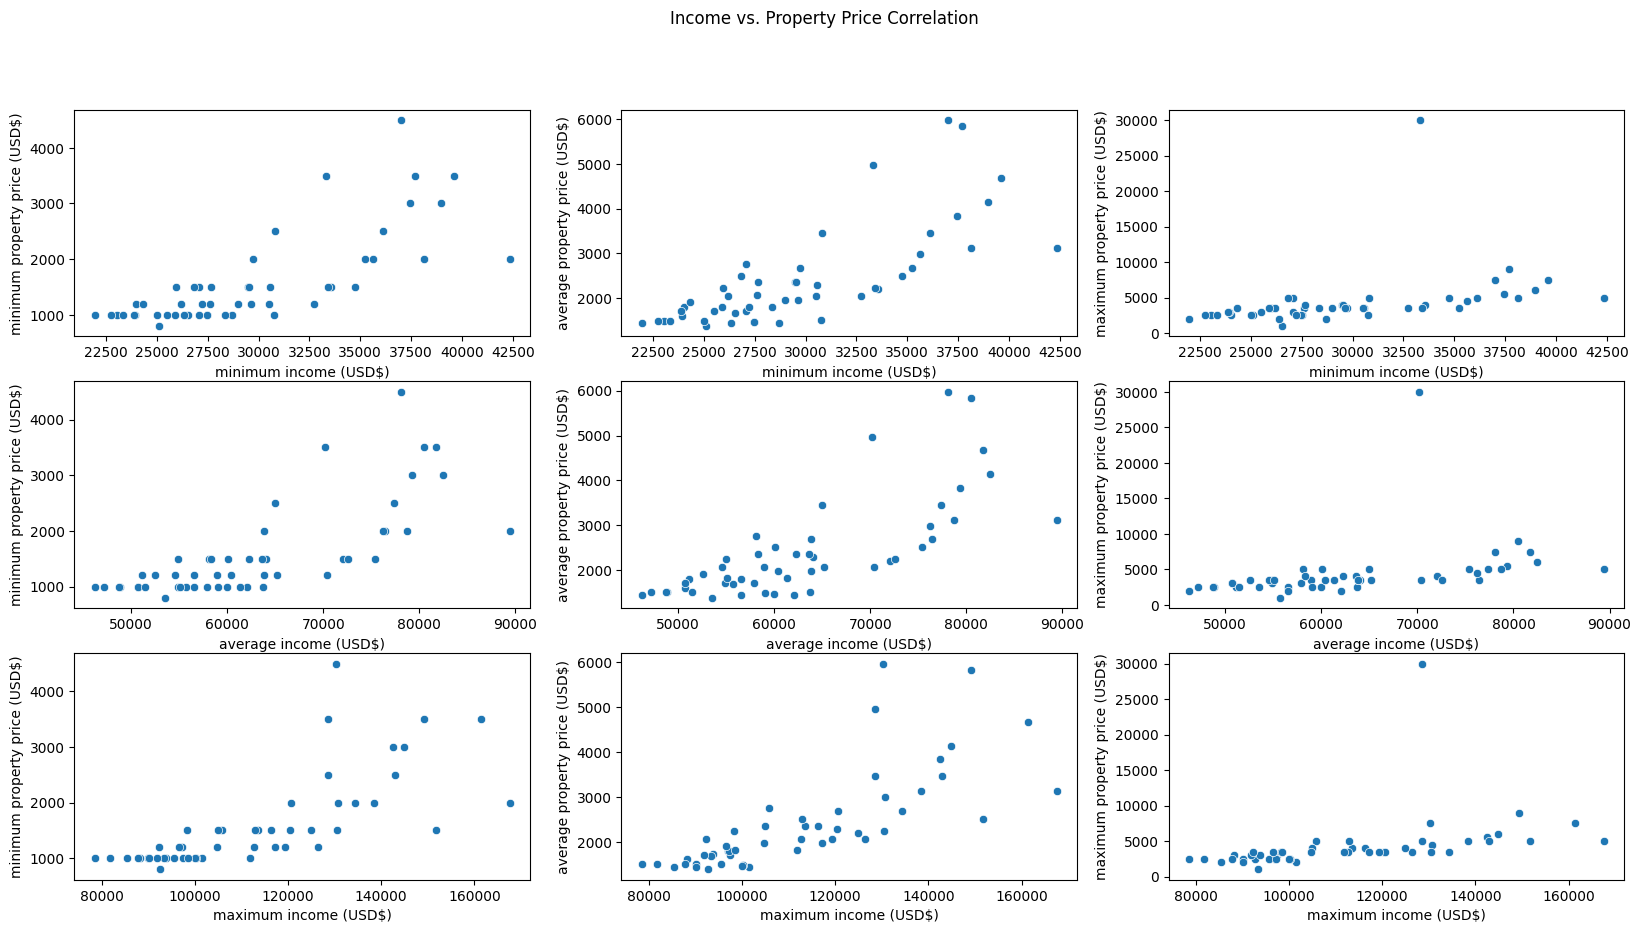

In [16]:
prefixes = ("minimum", "average", "maximum")
fig, ax = plt.subplots(nrows=len(prefixes), ncols=len(prefixes), figsize=(20, 10))
for i in range(len(prefixes)):
  for j in range(len(prefixes)):
    sns.scatterplot(data=property_income_data, x=prefixes[i] + '_income', y=prefixes[j] + '_property_price', ax=ax[i][j])
    ax[i][j].set_xlabel(prefixes[i] + " income (USD$)")
    ax[i][j].set_ylabel(prefixes[j] + " property price (USD$)")

plt.suptitle("Income vs. Property Price Correlation")

In [17]:
corruption_data = pd.read_csv("/content/drive/MyDrive/Refocus/Data Analytics/Final Project/Final Project - Lagmay/convictions.csv")
corruption_data

,state_usa,convictions_per_capita
0,Alabama,2.15
1,Alaska,1.06
2,Arizona,1.40
3,Arkansas,3.02
4,California,1.09
5,Colorado,0.80
6,Connecticut,2.01
7,Delaware,1.08
8,Florida,1.65
9,Georgia,1.60


In [18]:
corruption_data = corruption_data.drop_duplicates(subset="state_usa")
corruption_data

,state_usa,convictions_per_capita
0,Alabama,2.15
1,Alaska,1.06
2,Arizona,1.40
3,Arkansas,3.02
4,California,1.09
5,Colorado,0.80
6,Connecticut,2.01
7,Delaware,1.08
8,Florida,1.65
9,Georgia,1.60


In [19]:
property_health_corruption_data = property_income_data.merge(health_spending_data, on="state_usa")
property_health_corruption_data = property_health_corruption_data.merge(corruption_data, on="state_usa")
property_health_corruption_data

,state_usa,average_property_price,minimum_property_price,maximum_property_price,average_income,minimum_income,maximum_income,avg_health_spending,min_health_spending,max_health_spending,convictions_per_capita
0,Alabama,1797.50,1200.0,2500.0,51113,23999,96993,200.50,50.0,500.0,2.15
1,Alaska,2684.00,2000.0,3500.0,76440,35219,134318,300.25,100.0,750.0,1.06
2,Arizona,2356.75,1500.0,4000.0,62283,29466,113589,150.00,25.0,300.0,1.40
3,Arkansas,1499.25,1000.0,2500.0,48829,23028,90052,175.00,75.0,400.0,3.02
4,California,5832.50,3500.0,9000.0,80440,37698,149265,250.75,50.0,600.0,1.09
5,Colorado,2987.25,2000.0,4500.0,76240,35636,130714,225.50,100.0,500.0,0.80
6,Connecticut,3837.00,3000.0,5500.0,79287,37426,142596,300.00,150.0,700.0,2.01
7,Delaware,2289.75,1500.0,3500.0,64040,30544,120324,175.50,75.0,350.0,1.08
8,Florida,2763.50,1500.0,5000.0,58108,27064,105773,175.25,50.0,400.0,1.65
9,Georgia,2065.00,1200.0,3500.0,58932,27609,112609,200.00,75.0,450.0,1.60


In [20]:
rfm_data = property_health_corruption_data[['state_usa', 'average_property_price', 'minimum_property_price', 'maximum_property_price', 'avg_health_spending', 'min_health_spending', 'max_health_spending', 'convictions_per_capita']]
rfm_data = rfm_data.set_index("state_usa")
rfm_data

,average_property_price,minimum_property_price,maximum_property_price,avg_health_spending,min_health_spending,max_health_spending,convictions_per_capita
state_usa,,,,,,,
Alabama,1797.50,1200.0,2500.0,200.50,50.0,500.0,2.15
Alaska,2684.00,2000.0,3500.0,300.25,100.0,750.0,1.06
Arizona,2356.75,1500.0,4000.0,150.00,25.0,300.0,1.40
Arkansas,1499.25,1000.0,2500.0,175.00,75.0,400.0,3.02
California,5832.50,3500.0,9000.0,250.75,50.0,600.0,1.09
Colorado,2987.25,2000.0,4500.0,225.50,100.0,500.0,0.80
Connecticut,3837.00,3000.0,5500.0,300.00,150.0,700.0,2.01
Delaware,2289.75,1500.0,3500.0,175.50,75.0,350.0,1.08
Florida,2763.50,1500.0,5000.0,175.25,50.0,400.0,1.65


In [21]:
quantiles = rfm_data.quantile(q=[0.25, 0.5, 0.75])
quantiles

,average_property_price,minimum_property_price,maximum_property_price,avg_health_spending,min_health_spending,max_health_spending,convictions_per_capita
0.25,1684.5,1000.0,2500.0,175.25,50.0,362.5,1.0050
0.50,2056.5,1200.0,3500.0,200.25,75.0,450.0,1.3250
0.75,2684.0,1875.0,4875.0,244.50,100.0,575.0,1.9825


In [22]:
def rfm_score(dim, dim_quantiles):
    if dim <= dim_quantiles[0.25]:
        return '1'
    elif dim <= dim_quantiles[0.5]:
        return '2'
    elif dim <= dim_quantiles[0.75]:
        return '3'
    else:
        return '4'

In [23]:
corruptions_dict = quantiles['convictions_per_capita'].to_dict()
rfm_data['corruptions_score'] = rfm_data['convictions_per_capita'].apply(rfm_score, args=(corruptions_dict,))
rfm_data.head()

,average_property_price,minimum_property_price,maximum_property_price,avg_health_spending,min_health_spending,max_health_spending,convictions_per_capita,corruptions_score
state_usa,,,,,,,,
Alabama,1797.50,1200.0,2500.0,200.50,50.0,500.0,2.15,4
Alaska,2684.00,2000.0,3500.0,300.25,100.0,750.0,1.06,2
Arizona,2356.75,1500.0,4000.0,150.00,25.0,300.0,1.40,3
Arkansas,1499.25,1000.0,2500.0,175.00,75.0,400.0,3.02,4
California,5832.50,3500.0,9000.0,250.75,50.0,600.0,1.09,2


In [24]:
'''
def property_health_score(property_health, property_health_dict):
    if property_health <= property_health_dict[0.25]:
        return '4'
    elif property_health <= property_health_dict[0.5]:
        return '3'
    elif property_health <= property_health_dict[0.75]:
        return '2'
    else:
        return '1'
'''

"\ndef property_health_score(property_health, property_health_dict):\n    if property_health <= property_health_dict[0.25]:\n        return '4'\n    elif property_health <= property_health_dict[0.5]:\n        return '3'\n    elif property_health <= property_health_dict[0.75]:\n        return '2'\n    else:\n        return '1'\n"

In [25]:
prefixesProperty = prefixes
for prefix in prefixesProperty:
  property_price_dict = quantiles[prefix + '_property_price'].to_dict()
  rfm_data[prefix + '_property_price_score'] = rfm_data[prefix + '_property_price'].apply(rfm_score, args=(property_price_dict,))

rfm_data

,average_property_price,minimum_property_price,maximum_property_price,avg_health_spending,min_health_spending,max_health_spending,convictions_per_capita,corruptions_score,minimum_property_price_score,average_property_price_score,maximum_property_price_score
state_usa,,,,,,,,,,,
Alabama,1797.50,1200.0,2500.0,200.50,50.0,500.0,2.15,4,2,2,1
Alaska,2684.00,2000.0,3500.0,300.25,100.0,750.0,1.06,2,4,3,2
Arizona,2356.75,1500.0,4000.0,150.00,25.0,300.0,1.40,3,3,3,3
Arkansas,1499.25,1000.0,2500.0,175.00,75.0,400.0,3.02,4,1,1,1
California,5832.50,3500.0,9000.0,250.75,50.0,600.0,1.09,2,4,4,4
Colorado,2987.25,2000.0,4500.0,225.50,100.0,500.0,0.80,1,4,4,3
Connecticut,3837.00,3000.0,5500.0,300.00,150.0,700.0,2.01,4,4,4,4
Delaware,2289.75,1500.0,3500.0,175.50,75.0,350.0,1.08,2,3,3,2
Florida,2763.50,1500.0,5000.0,175.25,50.0,400.0,1.65,3,3,4,4


In [26]:
prefixesHealth = ('min', 'avg', 'max')
for prefix in prefixesHealth:
  health_spending_dict = quantiles[prefix + '_health_spending'].to_dict()
  rfm_data[prefix + '_health_spending_score'] = rfm_data[prefix + '_health_spending'].apply(rfm_score, args=(health_spending_dict,))

rfm_data

,average_property_price,minimum_property_price,maximum_property_price,avg_health_spending,min_health_spending,max_health_spending,convictions_per_capita,corruptions_score,minimum_property_price_score,average_property_price_score,maximum_property_price_score,min_health_spending_score,avg_health_spending_score,max_health_spending_score
state_usa,,,,,,,,,,,,,,
Alabama,1797.50,1200.0,2500.0,200.50,50.0,500.0,2.15,4,2,2,1,1,3,3
Alaska,2684.00,2000.0,3500.0,300.25,100.0,750.0,1.06,2,4,3,2,3,4,4
Arizona,2356.75,1500.0,4000.0,150.00,25.0,300.0,1.40,3,3,3,3,1,1,1
Arkansas,1499.25,1000.0,2500.0,175.00,75.0,400.0,3.02,4,1,1,1,2,1,2
California,5832.50,3500.0,9000.0,250.75,50.0,600.0,1.09,2,4,4,4,1,4,4
Colorado,2987.25,2000.0,4500.0,225.50,100.0,500.0,0.80,1,4,4,3,3,3,3
Connecticut,3837.00,3000.0,5500.0,300.00,150.0,700.0,2.01,4,4,4,4,4,4,4
Delaware,2289.75,1500.0,3500.0,175.50,75.0,350.0,1.08,2,3,3,2,2,2,1
Florida,2763.50,1500.0,5000.0,175.25,50.0,400.0,1.65,3,3,4,4,1,1,2


In [27]:
for prefixProperty in prefixesProperty:
  for prefixHealth in prefixesHealth:
    rfm_data['corruptions_' + prefixProperty + "_property_" + prefixHealth + "_health"] = rfm_data['corruptions_score'] + rfm_data[prefixProperty + '_property_price_score'] + rfm_data[prefixHealth + '_health_spending_score']

rfm_data

,average_property_price,minimum_property_price,maximum_property_price,avg_health_spending,min_health_spending,max_health_spending,convictions_per_capita,corruptions_score,minimum_property_price_score,average_property_price_score,...,max_health_spending_score,corruptions_minimum_property_min_health,corruptions_minimum_property_avg_health,corruptions_minimum_property_max_health,corruptions_average_property_min_health,corruptions_average_property_avg_health,corruptions_average_property_max_health,corruptions_maximum_property_min_health,corruptions_maximum_property_avg_health,corruptions_maximum_property_max_health
state_usa,,,,,,,,,,,,,,,,,,,,,
Alabama,1797.50,1200.0,2500.0,200.50,50.0,500.0,2.15,4,2,2,...,3,421,423,423,421,423,423,411,413,413
Alaska,2684.00,2000.0,3500.0,300.25,100.0,750.0,1.06,2,4,3,...,4,243,244,244,233,234,234,223,224,224
Arizona,2356.75,1500.0,4000.0,150.00,25.0,300.0,1.40,3,3,3,...,1,331,331,331,331,331,331,331,331,331
Arkansas,1499.25,1000.0,2500.0,175.00,75.0,400.0,3.02,4,1,1,...,2,412,411,412,412,411,412,412,411,412
California,5832.50,3500.0,9000.0,250.75,50.0,600.0,1.09,2,4,4,...,4,241,244,244,241,244,244,241,244,244
Colorado,2987.25,2000.0,4500.0,225.50,100.0,500.0,0.80,1,4,4,...,3,143,143,143,143,143,143,133,133,133
Connecticut,3837.00,3000.0,5500.0,300.00,150.0,700.0,2.01,4,4,4,...,4,444,444,444,444,444,444,444,444,444
Delaware,2289.75,1500.0,3500.0,175.50,75.0,350.0,1.08,2,3,3,...,1,232,232,231,232,232,231,222,222,221
Florida,2763.50,1500.0,5000.0,175.25,50.0,400.0,1.65,3,3,4,...,2,331,331,332,341,341,342,341,341,342


In [28]:
rfm_data = rfm_data.drop(['average_property_price', 'minimum_property_price', 'maximum_property_price', 'avg_health_spending', 'min_health_spending', 'max_health_spending', 'convictions_per_capita'], axis=1)
rfm_data

,corruptions_score,minimum_property_price_score,average_property_price_score,maximum_property_price_score,min_health_spending_score,avg_health_spending_score,max_health_spending_score,corruptions_minimum_property_min_health,corruptions_minimum_property_avg_health,corruptions_minimum_property_max_health,corruptions_average_property_min_health,corruptions_average_property_avg_health,corruptions_average_property_max_health,corruptions_maximum_property_min_health,corruptions_maximum_property_avg_health,corruptions_maximum_property_max_health
state_usa,,,,,,,,,,,,,,,,
Alabama,4,2,2,1,1,3,3,421,423,423,421,423,423,411,413,413
Alaska,2,4,3,2,3,4,4,243,244,244,233,234,234,223,224,224
Arizona,3,3,3,3,1,1,1,331,331,331,331,331,331,331,331,331
Arkansas,4,1,1,1,2,1,2,412,411,412,412,411,412,412,411,412
California,2,4,4,4,1,4,4,241,244,244,241,244,244,241,244,244
Colorado,1,4,4,3,3,3,3,143,143,143,143,143,143,133,133,133
Connecticut,4,4,4,4,4,4,4,444,444,444,444,444,444,444,444,444
Delaware,2,3,3,2,2,2,1,232,232,231,232,232,231,222,222,221
Florida,3,3,4,4,1,1,2,331,331,332,341,341,342,341,341,342


In [29]:
print("Best States")
for prefixProperty in prefixesProperty:
  for prefixHealth in prefixesHealth:
    print(rfm_data[['corruptions_' + prefixProperty + '_property_' + prefixHealth + '_health']].loc[rfm_data['corruptions_' + prefixProperty + '_property_' + prefixHealth + '_health'] == '111'])

Best States
             corruptions_minimum_property_min_health
state_usa                                           
Iowa                                             111
Nebraska                                         111
North Dakota                                     111
South Dakota                                     111
             corruptions_minimum_property_avg_health
state_usa                                           
Iowa                                             111
North Dakota                                     111
South Dakota                                     111
             corruptions_minimum_property_max_health
state_usa                                           
Iowa                                             111
Nebraska                                         111
North Dakota                                     111
South Dakota                                     111
             corruptions_average_property_min_health
state_usa                         

In [30]:
print("Low-Expense States")
for prefixProperty in prefixesProperty:
  for prefixHealth in prefixesHealth:
    print(rfm_data[['corruptions_' + prefixProperty + '_property_' + prefixHealth + '_health']].loc[(rfm_data[prefixProperty + '_property_price_score'] == '1') & (rfm_data[prefixHealth + '_health_spending_score'] == '1')])

Low-Expense States
             corruptions_minimum_property_min_health
state_usa                                           
Idaho                                            211
Iowa                                             111
Kansas                                           211
Mississippi                                      411
Montana                                          211
Nebraska                                         111
North Dakota                                     111
Oklahoma                                         411
South Dakota                                     111
Tennessee                                        411
              corruptions_minimum_property_avg_health
state_usa                                            
Arkansas                                          411
Idaho                                             211
Iowa                                              111
Kentucky                                          311
Mississippi          

In [31]:
print("Almost Corrupt States")
for prefixProperty in prefixesProperty:
  for prefixHealth in prefixesHealth:
    print(rfm_data[['corruptions_' + prefixProperty + '_property_' + prefixHealth + '_health']].loc[rfm_data['corruptions_' + prefixProperty + '_property_' + prefixHealth + '_health'] == '311'])

Almost Corrupt States
Empty DataFrame
Columns: [corruptions_minimum_property_min_health]
Index: []
          corruptions_minimum_property_avg_health
state_usa                                        
Kentucky                                      311
Empty DataFrame
Columns: [corruptions_minimum_property_max_health]
Index: []
Empty DataFrame
Columns: [corruptions_average_property_min_health]
Index: []
          corruptions_average_property_avg_health
state_usa                                        
Kentucky                                      311
Empty DataFrame
Columns: [corruptions_average_property_max_health]
Index: []
Empty DataFrame
Columns: [corruptions_maximum_property_min_health]
Index: []
Empty DataFrame
Columns: [corruptions_maximum_property_avg_health]
Index: []
Empty DataFrame
Columns: [corruptions_maximum_property_max_health]
Index: []


In [32]:
print("Corrupt States")
for prefixProperty in prefixesProperty:
  for prefixHealth in prefixesHealth:
    print(rfm_data[['corruptions_' + prefixProperty + '_property_' + prefixHealth + '_health']].loc[rfm_data['corruptions_' + prefixProperty + '_property_' + prefixHealth + '_health'] == '411'])

Corrupt States
            corruptions_minimum_property_min_health
state_usa                                          
Mississippi                                     411
Oklahoma                                        411
Tennessee                                       411
              corruptions_minimum_property_avg_health
state_usa                                            
Arkansas                                          411
Mississippi                                       411
New Mexico                                        411
Tennessee                                         411
West Virginia                                     411
            corruptions_minimum_property_max_health
state_usa                                          
Mississippi                                     411
Oklahoma                                        411
            corruptions_average_property_min_health
state_usa                                          
Mississippi                        

In [33]:
print("Corrupt High-Expense States")
for prefixProperty in prefixesProperty:
  for prefixHealth in prefixesHealth:
    print(rfm_data[['corruptions_' + prefixProperty + '_property_' + prefixHealth + '_health']].loc[rfm_data['corruptions_' + prefixProperty + '_property_' + prefixHealth + '_health'] == '444'])

Corrupt High-Expense States
              corruptions_minimum_property_min_health
state_usa                                            
Connecticut                                       444
Massachusetts                                     444
Rhode Island                                      444
              corruptions_minimum_property_avg_health
state_usa                                            
Connecticut                                       444
Massachusetts                                     444
Rhode Island                                      444
Washington                                        444
              corruptions_minimum_property_max_health
state_usa                                            
Connecticut                                       444
Massachusetts                                     444
Rhode Island                                      444
Washington                                        444
              corruptions_average_property_min_health


In [34]:
rfm_data_corruption_states = rfm_data.reset_index().groupby(['corruptions_score'])['state_usa'].count().to_frame('total_states').reset_index()
rfm_data_corruption_states

,corruptions_score,total_states
0,1,13
1,2,12
2,3,12
3,4,13


Text(0.5, 0.98, 'Health Spending and Corruption Scores')

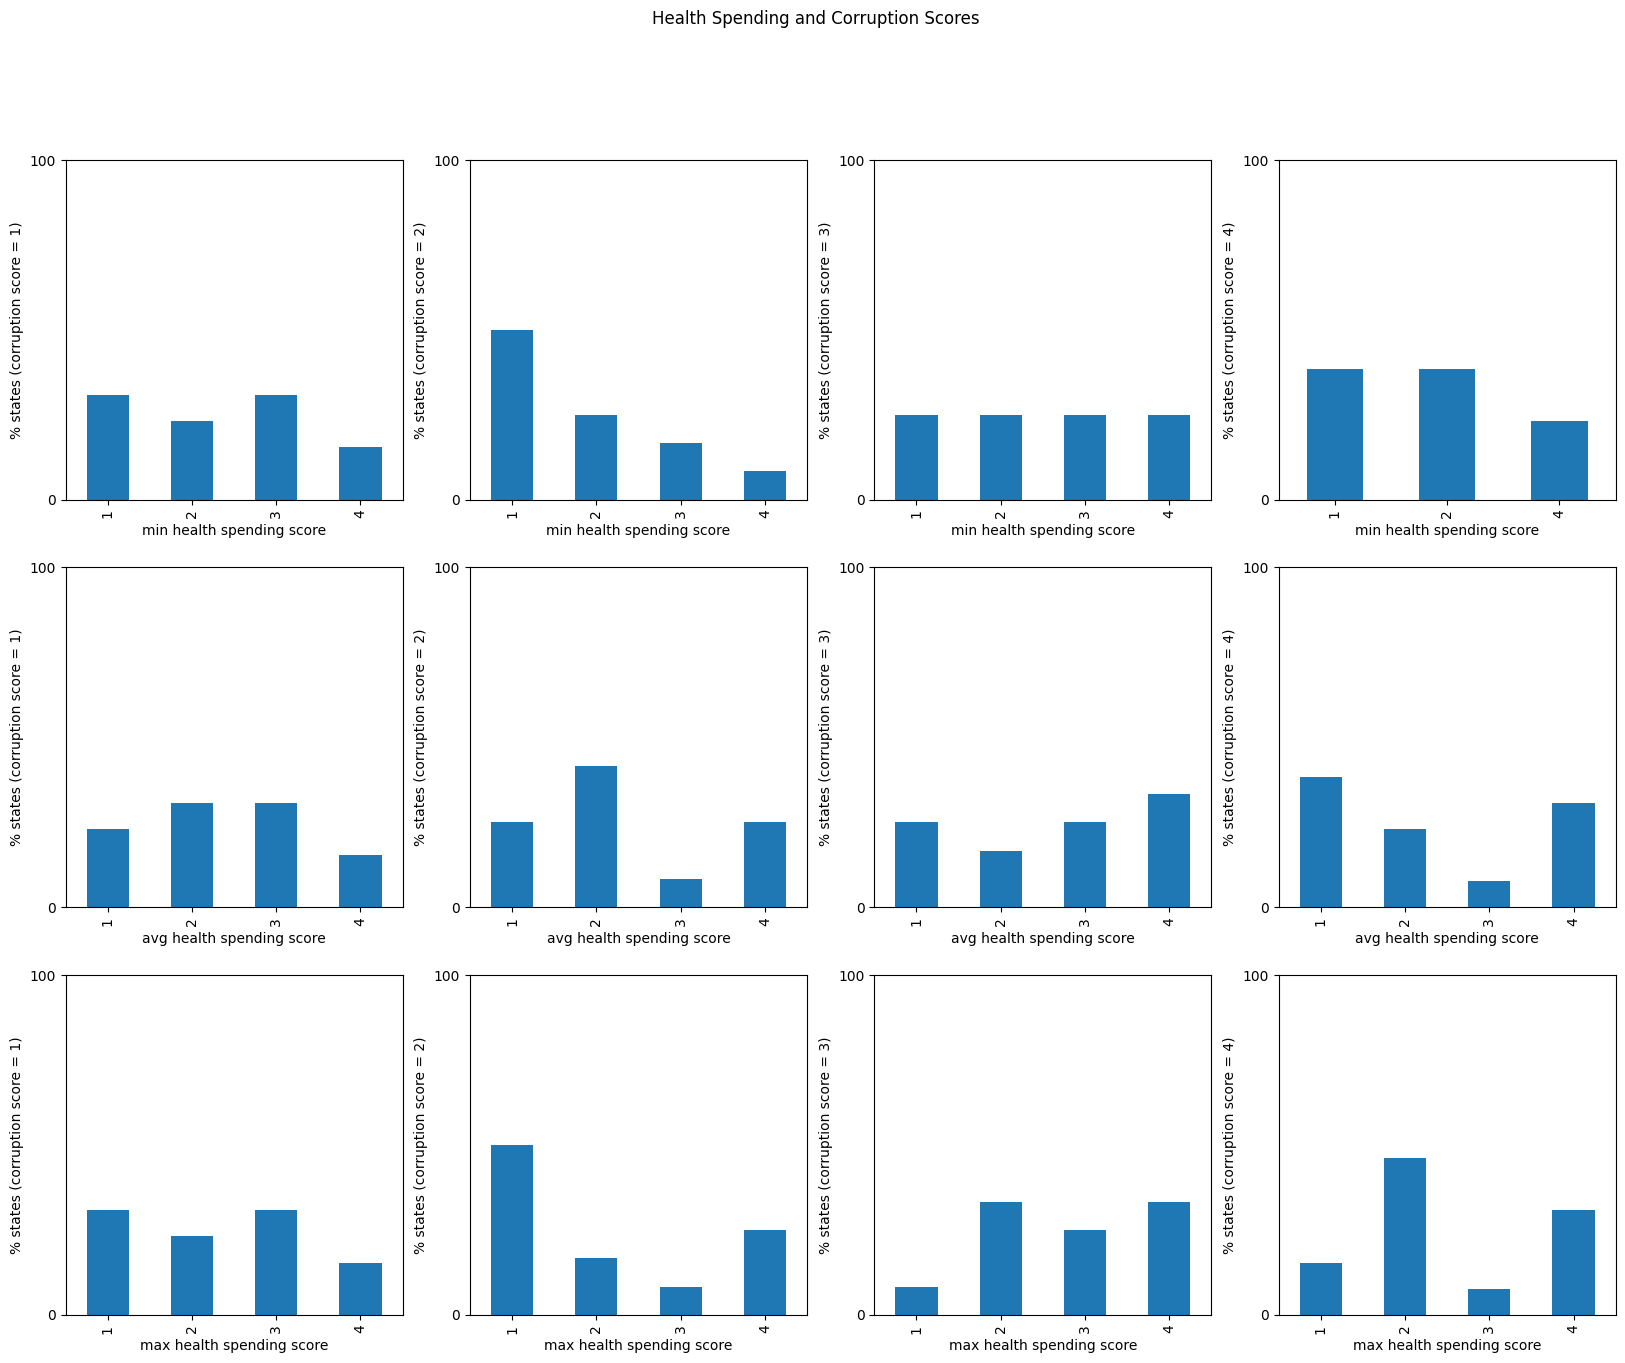

In [35]:
fig, ax = plt.subplots(nrows=len(prefixesHealth), ncols=4, figsize=(20, 15))
for i in range(len(prefixesHealth)):
  for j in range(1, 5):
    rfm_data_corruption_health = rfm_data.loc[rfm_data['corruptions_score'] == str(j)].reset_index().groupby([prefixesHealth[i] + '_health_spending_score', 'corruptions_score'])['state_usa'].count().to_frame('subtotal_states').reset_index()
    rfm_data_corruption_health = rfm_data_corruption_health.merge(rfm_data_corruption_states, on='corruptions_score')
    rfm_data_corruption_health['pct_states'] = (rfm_data_corruption_health['subtotal_states'] / rfm_data_corruption_health['total_states']) * 100
    rfm_data_corruption_health.set_index(prefixesHealth[i] + '_health_spending_score')[['pct_states']].plot(kind='bar', ax=ax[i][j - 1])
    ax[i][j - 1].set_xlabel(prefixesHealth[i] + " health spending score")
    ax[i][j - 1].set_yticks((0, 100))
    ax[i][j - 1].set_ylabel("% states (corruption score = " + str(j) + ")")
    ax[i][j - 1].legend().remove()

plt.suptitle("Health Spending and Corruption Scores")